# Au diffusion on Al(001): constrained scans and CI-NEB

This notebook follows a gold adatom as it moves between neighboring adsorption sites on an Al(001) surface. It first uses forward and reverse constrained scans to inspect the energy landscape, then uses those structures to initialize a climbing-image nudged elastic band (CI-NEB) calculation of the diffusion pathway.

> **Method scope.** The constrained scans are diagnostics, not minimum-energy paths: each scan structure is relaxed independently at a fixed Au $x$ coordinate. The later CI-NEB calculation couples the images with spring forces and releases the Au $x$ constraint so that the pathway can relax toward a saddle point.

The diffusion direction is the first cell vector, here treated as the $x$ direction. Distances are in angstrom, forces are in eV/Å, and ASE energies are in eV. Energy differences are converted explicitly to meV only for plotting.

## Building the surface model

The starting structure is a $2 \times 2$ Al(001) slab with three atomic layers. An Au atom is placed $1.7$ Å above a fourfold hollow site, and $4.0$ Å of vacuum is added on each side normal to the surface. The EMT calculator is attached later, immediately before relaxation.

In [1]:
from ase.build import add_adsorbate, fcc100
from ase.calculators.emt import EMT
from ase.constraints import FixAtoms, FixedPlane
from ase.optimize import QuasiNewton

# 2x2-Al(001) surface with 3 layers and an
# Au atom adsorbed in a hollow site:
slab = fcc100('Al', size=(2, 2, 3))
add_adsorbate(slab, 'Au', 1.7, 'hollow')
slab.center(axis=2, vacuum=4.0)

### Inspecting the initial geometry

The top view shows the Au adsorption site within the periodic surface cell, while the side view makes the slab thickness and vacuum direction visible. The `-90x` rotation changes only the plotted viewpoint; it does not rotate or modify the stored atomic coordinates.

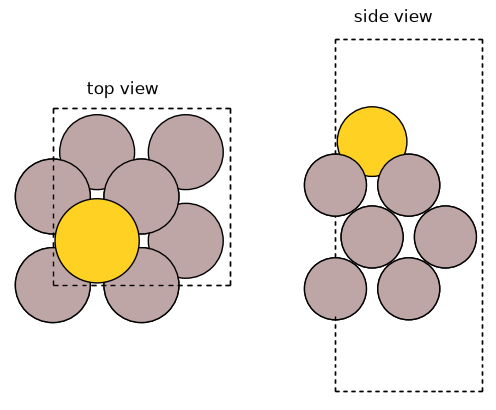

In [2]:
import matplotlib.pyplot as plt

from ase.visualize.plot import plot_atoms

fig, (ax1, ax2) = plt.subplots(1, 2)
plot_atoms(slab, ax1)
plot_atoms(slab, ax2, rotation='-90x')
ax1.set_title('top view')
ax2.set_title('side view')
ax1.set_axis_off()
ax2.set_axis_off()

## Constraining the substrate and scan coordinate

ASE assigns layer tags when constructing this slab. The mask `atom.tag > 1` selects the second and third Al layers, and `FixAtoms` freezes all their Cartesian coordinates. The upper Al layer remains free to respond to the adsorbate.

`FixedPlane(-1, (1, 0, 0))` constrains the last atom—the Au adatom—to a plane whose normal is along $x$. Its $x$ coordinate is therefore fixed during each relaxation, while its $y$ and $z$ coordinates may relax. Combining both constraints turns the Au $x$ position into the scan coordinate.

In [3]:
# Fix second and third layers:
mask = [atom.tag > 1 for atom in slab]
# print(mask)
fixlayers = FixAtoms(mask=mask)

# Constrain the last atom (Au atom) to move only in the yz-plane:
plane = FixedPlane(-1, (1, 0, 0))

slab.set_constraint([fixlayers, plane])

## Generating the constrained scan

EMT supplies energies and forces. Nine positions span half of the periodic cell, so neighboring constrained images are separated by $L_x/16$. At every position, `QuasiNewton` relaxes the unconstrained coordinates to `fmax = 0.01` eV/Å, a tighter tolerance than the original five-image scan.

The forward scan moves from one hollow site toward its periodic equivalent. The reverse scan starts from the relaxed forward endpoint and traverses the same coordinates in the opposite order. Each direction is warm-started from its preceding relaxed structure, so disagreement at the same Au displacement reveals scan-direction hysteresis or incomplete relaxation.

The final frame at every position is saved as `scan_forward_*.traj` or `scan_reverse_*.traj`; matching log files record the optimizer history. The helper does not move the Au atom after the last image. `configs` retains the forward images for the animation, and repeating them by $(2, 1, 1)$ changes only the visualization.

In [4]:
from pathlib import Path

from ase.io import read

output_dir = Path('../files/advanced/tutorial_04')
output_dir.mkdir(parents=True, exist_ok=True)

n_scan_images = 9
scan_fmax = 0.01  # eV/Å
scan_step = slab.cell[0, 0] / (2 * (n_scan_images - 1))


def run_constrained_scan(start, step, label):
    """Relax one directional scan and return its final images."""
    image = start.copy()
    image.calc = EMT()
    relaxed_images = []

    for index in range(n_scan_images):
        trajectory = output_dir / f'scan_{label}_{index:02d}.traj'
        logfile = output_dir / f'scan_{label}_{index:02d}.log'
        optimizer = QuasiNewton(
            image, trajectory=trajectory, logfile=logfile
        )
        optimizer.run(fmax=scan_fmax)
        relaxed_images.append(read(trajectory, index=-1))

        if index < n_scan_images - 1:
            image[-1].x += step

    return relaxed_images


forward_configs = run_constrained_scan(slab, scan_step, 'forward')
reverse_start = forward_configs[-1].copy()
reverse_configs = run_constrained_scan(reverse_start, -scan_step, 'reverse')

# Retain the forward scan for the animation below.
configs = forward_configs
configs_repeated = [config.repeat((2, 1, 1)) for config in configs]

## Animating the relaxed images

`animate` returns a Matplotlib `FuncAnimation`. Converting it with `to_jshtml()` embeds the frames and playback controls directly in the notebook, so this display route does not depend on the external ASE GUI or Tk. The nine forward-scan images are shown at $500$ ms intervals from a side view. The reverse scan is omitted from the animation because it retraces the same Au coordinates.

In [5]:
import matplotlib.pyplot as plt
from IPython.display import HTML
from ase.visualize.plot import animate

fig, ax = plt.subplots()

anim = animate(
    configs_repeated,
    ax=None,
    interval=500,  # in ms; same default value as in FuncAnimation
    rotation=('-90x,0y,0z'),
)

plt.close(fig)  # Avoid displaying an extra static figure
HTML(anim.to_jshtml())

## Plotting the relative energy profile

For each stored structure, the horizontal coordinate is the relaxed Au position relative to the first forward image:

$$
\Delta x_i = x_i^{\mathrm{Au}} - x_0^{\mathrm{Au}}.
$$

The plotted energy is referenced to the lowest energy found across both directions and converted from eV to meV:

$$
\Delta E_i = 1000\left(E_i - E_{\mathrm{min}}\right) \; \mathrm{meV}.
$$

Plotting forward and reverse scans against the same physical coordinate makes hysteresis visible directly. The maximum energy difference between matched displacements is reported below as a simple directional-consistency check.

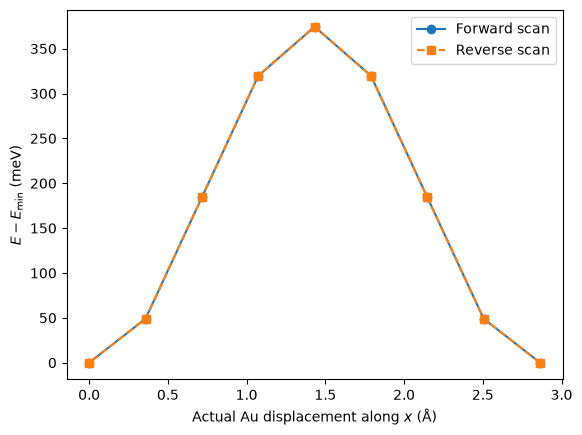

Forward sampled barrier: 0.3744 eV
Reverse sampled barrier: 0.3745 eV
Maximum forward/reverse difference: 0.07 meV


In [6]:
import numpy as np

forward_x = np.array([config[-1].x for config in forward_configs])
reverse_x = np.array([config[-1].x for config in reverse_configs])
x_origin = forward_x[0]
forward_displacements = forward_x - x_origin
reverse_displacements = reverse_x - x_origin

forward_energies = np.array(
    [config.get_potential_energy() for config in forward_configs]
)
reverse_energies = np.array(
    [config.get_potential_energy() for config in reverse_configs]
)
scan_reference_energy = min(forward_energies.min(), reverse_energies.min())
forward_relative_mev = 1000 * (forward_energies - scan_reference_energy)
reverse_relative_mev = 1000 * (reverse_energies - scan_reference_energy)

fig, ax = plt.subplots()
ax.plot(
    forward_displacements, forward_relative_mev, 'o-', label='Forward scan'
)
ax.plot(
    reverse_displacements, reverse_relative_mev, 's--', label='Reverse scan'
)
ax.set_xlabel(r'Actual Au displacement along $x$ (Å)')
ax.set_ylabel(r'$E - E_{\mathrm{min}}$ (meV)')
ax.legend()
plt.show()

forward_barrier = forward_energies.max() - forward_energies[0]
reverse_barrier = reverse_energies.max() - reverse_energies[0]
scan_hysteresis = np.max(
    np.abs(forward_energies - reverse_energies[::-1])
)
print(f'Forward sampled barrier: {forward_barrier:.4f} eV')
print(f'Reverse sampled barrier: {reverse_barrier:.4f} eV')
print(f'Maximum forward/reverse difference: {1000 * scan_hysteresis:.2f} meV')

## From constrained scans to climbing-image NEB

The denser scan resolves the profile more finely, while the forward/reverse comparison tests whether the sequential relaxations follow the same local branch. Similar curves support the scan's numerical consistency, but even perfect agreement would not make the scan a minimum-energy path because every image still fixes the Au $x$ coordinate independently.

The nine forward structures now provide physically sensible starting images for NEB. For every NEB image, the deeper Al layers remain fixed, but `FixedPlane` is removed so that Au and the upper Al layer can relax in all available Cartesian directions. Separate EMT calculators are attached because NEB evaluates every image.

A standard NEB is first optimized to `fmax = 0.03` eV/Å. The calculation then enables `climb=True`, creates a fresh optimizer, and tightens the convergence criterion to `fmax = 0.01` eV/Å. During this second stage, the highest-energy image is driven uphill along the path tangent and downhill perpendicular to it, locating the saddle point more directly than a constrained scan. The spring constant is $0.1$ eV/Å$^2$.

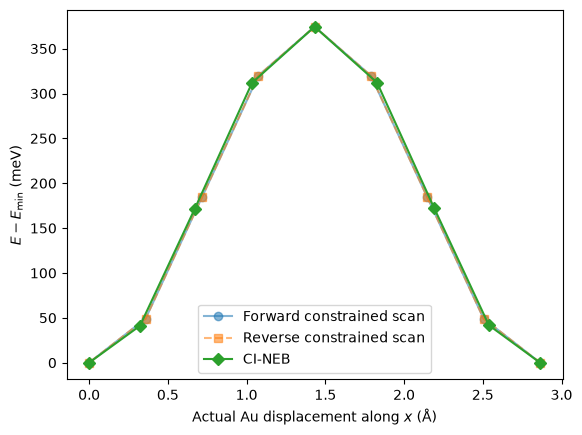

Standard NEB converged: True
Climbing-image NEB converged: True
CI-NEB barrier from the initial state: 0.3744 eV
Final minus initial endpoint energy: -0.0001 eV


In [7]:
from ase.mep import NEB, NEBTools
from ase.optimize import BFGS

neb_images = [config.copy() for config in forward_configs]
for image in neb_images:
    fixed_mask = [atom.tag > 1 for atom in image]
    image.set_constraint(FixAtoms(mask=fixed_mask))
    image.calc = EMT()

neb = NEB(neb_images, k=0.1, method='improvedtangent', climb=False)
pre_optimizer = BFGS(
    neb,
    trajectory=output_dir / 'neb_preclimb.traj',
    logfile=output_dir / 'neb_preclimb.log',
)
pre_converged = pre_optimizer.run(fmax=0.03, steps=300)

neb.climb = True
ci_optimizer = BFGS(
    neb,
    trajectory=output_dir / 'neb_climb.traj',
    logfile=output_dir / 'neb_climb.log',
)
ci_converged = ci_optimizer.run(fmax=0.01, steps=300)

neb_x = np.array([image[-1].x for image in neb_images])
neb_displacements = neb_x - x_origin
neb_energies = np.array(
    [image.get_potential_energy() for image in neb_images]
)
energy_reference = min(scan_reference_energy, neb_energies.min())

fig, ax = plt.subplots()
ax.plot(
    forward_displacements,
    1000 * (forward_energies - energy_reference),
    'o-',
    alpha=0.55,
    label='Forward constrained scan',
)
ax.plot(
    reverse_displacements,
    1000 * (reverse_energies - energy_reference),
    's--',
    alpha=0.55,
    label='Reverse constrained scan',
)
ax.plot(
    neb_displacements,
    1000 * (neb_energies - energy_reference),
    'D-',
    label='CI-NEB',
)
ax.set_xlabel(r'Actual Au displacement along $x$ (Å)')
ax.set_ylabel(r'$E - E_{\mathrm{min}}$ (meV)')
ax.legend()
plt.show()

neb_tools = NEBTools(neb_images)
neb_barrier, endpoint_difference = neb_tools.get_barrier(fit=False)
print(f'Standard NEB converged: {pre_converged}')
print(f'Climbing-image NEB converged: {ci_converged}')
print(f'CI-NEB barrier from the initial state: {neb_barrier:.4f} eV')
print(f'Final minus initial endpoint energy: {endpoint_difference:.4f} eV')

## Interpreting the CI-NEB pathway

`NEBTools.get_barrier(fit=False)` reports the highest discrete NEB-image energy relative to the initial endpoint, while the endpoint difference is $E_{\mathrm{final}} - E_{\mathrm{initial}}$. Equivalent hollow sites should have a small endpoint difference; a substantial value would signal residual endpoint asymmetry or insufficient convergence.

In this run, the forward and reverse sampled barriers are $0.3744$ and $0.3745$ eV, and their largest energy disagreement at a matched displacement is only $0.07$ meV. Both NEB stages converge; CI-NEB gives a barrier of $0.3744$ eV and an endpoint difference of $-0.0001$ eV. The close endpoints and negligible scan hysteresis are consistent with a symmetric, well-relaxed hop in this EMT model.

The comparison plot still uses the actual Au $x$ displacement so that the constrained scans and CI-NEB can share one horizontal axis. This is an intuitive coordinate for the present hop, but it is not the complete multidimensional reaction coordinate: the CI-NEB also includes coupled motion of Au in $y$ and $z$ and relaxation of the upper Al layer.

The CI-NEB barrier is the appropriate pathway estimate from this notebook. The constrained-scan maxima remain useful as initialization and diagnostics, but they may sit above the NEB path because the fixed-plane constraint prevents each image from relaxing freely along the pathway.

## Takeaways and convergence checks

- The nine-image forward/reverse scans use `fmax = 0.01` eV/Å and plot energy in correctly converted meV against the actual Au displacement.
- `FixAtoms` keeps the deeper substrate layers rigid. `FixedPlane` defines the constrained-scan coordinate but is deliberately removed from the NEB images.
- Forward/reverse agreement tests directional hysteresis; it does not replace a pathway optimization.
- The two-stage NEB first stabilizes the elastic band, then activates the climbing image and converges the saddle search to `fmax = 0.01` eV/Å.
- For a convergence study, increase the NEB image count and vary the spring constant, slab thickness, lateral cell size, number of relaxed layers, and force tolerance.
- EMT is useful for learning the workflow, but its Au/Al barrier should not automatically be treated as quantitatively predictive. A research calculation should repeat the converged protocol with a validated calculator.